In [1]:
# Imports and Configuration
import struct
import numpy as np
import pyshark
import pandas as pd
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple, List, Optional
import nest_asyncio
from collections import defaultdict, deque
import struct
from typing import List, Tuple, Optional

nest_asyncio.apply()

# Configure plotting
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# Exp1: window size and accuracy

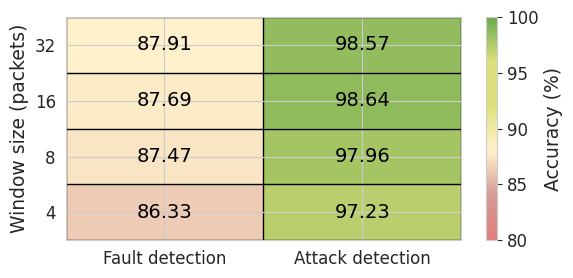

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Data
ws = [4, 8, 16, 32][::-1]
features = ['Fault detection', 'Attack detection']

accuracy = np.array([
    [87.9105, 98.5733],
    [87.6871, 98.6409],
    [87.4732, 97.9613],
    [86.3281, 97.2318]
])

# hex_colors = ["#fff2cc", "#fff2cc", "#6aa84f", "#6aa84f"]
# cmap = LinearSegmentedColormap.from_list("custom_green", hex_colors)
# ---- Custom hex colormap ----
hex_colors = ["#E17E7B", "#D69997", "#fff2cc", "#dee17b","#dee17b", "#6aa84f"]
cmap = LinearSegmentedColormap.from_list("custom_blue", hex_colors)
# cmap = LinearSegmentedColormap.from_list(
#     "ylgn_custom",
#     ["#fff7cc", "#c2e699", "#78c679", "#238443"]
# )

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 13.5,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(6, 3))

im = ax.imshow(
    accuracy,
    aspect='auto',
    cmap=cmap,
    vmin=80,
    vmax=100,
    interpolation='nearest'
)

# Cell borders
ax.set_xticks(np.arange(-0.5, len(features), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(ws), 1), minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# Labels and ticks
ax.set_ylabel('Window size (packets)')
ax.set_xticks(np.arange(len(features)))
ax.set_xticklabels(features)
ax.set_yticks(np.arange(len(ws)))
ax.set_yticklabels(ws)

# Colorbar
cbar = fig.colorbar(im, ax=ax, ticks=[80,85,90,95,100])
cbar.set_label('Accuracy (%)', fontsize=13.5)

# Annotate cells
for i in range(len(ws)):
    for j in range(len(features)):
        ax.text(j, i, f"{accuracy[i, j]:.2f}",
                ha="center", va="center", color="black")

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.savefig('exp1_ws_acc/ws_accuracy.pdf', dpi=300)
plt.show()

# Exp 2: accuracy at different tree sizes and window sizesfor RF wih 8 features

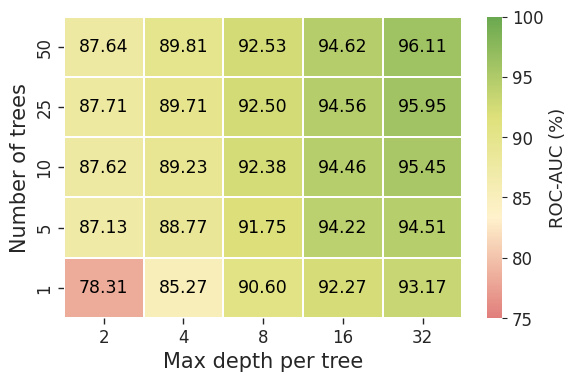

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Hardcoded data
data = [
    {"n_estimators": 1,  "max_depth": 2,  "roc_auc": 78.31},
    {"n_estimators": 1,  "max_depth": 4,  "roc_auc": 85.27},
    {"n_estimators": 1,  "max_depth": 8,  "roc_auc": 90.60},
    {"n_estimators": 1,  "max_depth": 16, "roc_auc": 92.27},
    {"n_estimators": 1,  "max_depth": 32, "roc_auc": 93.17},

    {"n_estimators": 5,  "max_depth": 2,  "roc_auc": 87.13},
    {"n_estimators": 5,  "max_depth": 4,  "roc_auc": 88.77},
    {"n_estimators": 5,  "max_depth": 8,  "roc_auc": 91.75},
    {"n_estimators": 5,  "max_depth": 16, "roc_auc": 94.22},
    {"n_estimators": 5,  "max_depth": 32, "roc_auc": 94.51},

    {"n_estimators": 10, "max_depth": 2,  "roc_auc": 87.62},
    {"n_estimators": 10, "max_depth": 4,  "roc_auc": 89.23},
    {"n_estimators": 10, "max_depth": 8,  "roc_auc": 92.38},
    {"n_estimators": 10, "max_depth": 16, "roc_auc": 94.46},
    {"n_estimators": 10, "max_depth": 32, "roc_auc": 95.45},

    {"n_estimators": 25, "max_depth": 2,  "roc_auc": 87.71},
    {"n_estimators": 25, "max_depth": 4,  "roc_auc": 89.71},
    {"n_estimators": 25, "max_depth": 8,  "roc_auc": 92.50},
    {"n_estimators": 25, "max_depth": 16, "roc_auc": 94.56},
    {"n_estimators": 25, "max_depth": 32, "roc_auc": 95.95},

    {"n_estimators": 50, "max_depth": 2,  "roc_auc": 87.64},
    {"n_estimators": 50, "max_depth": 4,  "roc_auc": 89.81},
    {"n_estimators": 50, "max_depth": 8,  "roc_auc": 92.53},
    {"n_estimators": 50, "max_depth": 16, "roc_auc": 94.62},
    {"n_estimators": 50, "max_depth": 32, "roc_auc": 96.11},
]

df = pd.DataFrame(data)

# Pivot
pivot = df.pivot_table(
    index='n_estimators',
    columns='max_depth',
    values='roc_auc',
    aggfunc='mean'
).sort_index().sort_index(axis=1)

# ---- Font sizes ----
plt.rcParams.update({
    "font.size": 12.5,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# ---- Custom colormap ----
hex_colors = ["#E17E7B", "#fff2cc", "#dee17b", "#6aa84f"]
cmap = LinearSegmentedColormap.from_list("custom_colormap", hex_colors)

# Plot
plt.figure(figsize=(6, 4))
ax = sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=75, vmax=100,
    linewidths=0.003,
    annot_kws={"color": "black"},
    cbar_kws={"label": "ROC-AUC (%)"}
)

ax.tick_params(
    axis='both',
    which='both',
    direction='out',
    length=4,
    width=1,
    bottom=True,
    top=False,
    left=True,
    right=False
)

ax.set_xlabel("Max depth per tree")
ax.set_ylabel("Number of trees")
ax.invert_yaxis()

# Colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("ROC-AUC (%)", fontsize=13)

plt.tight_layout()
plt.savefig("exp2_tree_size/fault_roc_auc_heatmap_8f_ws8.pdf.pdf", dpi=300)
plt.show()

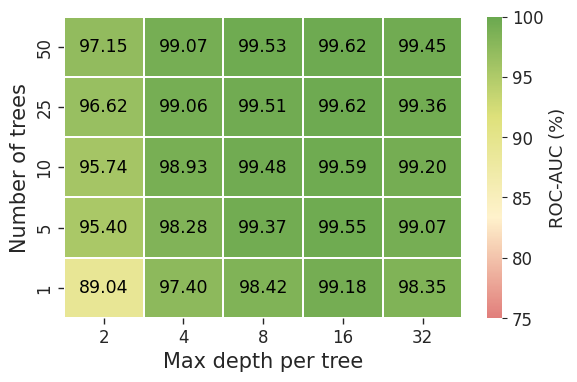

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Hardcoded data
data = [
    {"n_estimators": 1,  "max_depth": 2,  "roc_auc": 89.04},
    {"n_estimators": 1,  "max_depth": 4,  "roc_auc": 97.40},
    {"n_estimators": 1,  "max_depth": 8,  "roc_auc": 98.42},
    {"n_estimators": 1,  "max_depth": 16, "roc_auc": 99.18},
    {"n_estimators": 1,  "max_depth": 32, "roc_auc": 98.35},

    {"n_estimators": 5,  "max_depth": 2,  "roc_auc": 95.40},
    {"n_estimators": 5,  "max_depth": 4,  "roc_auc": 98.28},
    {"n_estimators": 5,  "max_depth": 8,  "roc_auc": 99.37},
    {"n_estimators": 5,  "max_depth": 16, "roc_auc": 99.55},
    {"n_estimators": 5,  "max_depth": 32, "roc_auc": 99.07},

    {"n_estimators": 10, "max_depth": 2,  "roc_auc": 95.74},
    {"n_estimators": 10, "max_depth": 4,  "roc_auc": 98.93},
    {"n_estimators": 10, "max_depth": 8,  "roc_auc": 99.48},
    {"n_estimators": 10, "max_depth": 16, "roc_auc": 99.59},
    {"n_estimators": 10, "max_depth": 32, "roc_auc": 99.20},

    {"n_estimators": 25, "max_depth": 2,  "roc_auc": 96.62},
    {"n_estimators": 25, "max_depth": 4,  "roc_auc": 99.06},
    {"n_estimators": 25, "max_depth": 8,  "roc_auc": 99.51},
    {"n_estimators": 25, "max_depth": 16, "roc_auc": 99.62},
    {"n_estimators": 25, "max_depth": 32, "roc_auc": 99.36},

    {"n_estimators": 50, "max_depth": 2,  "roc_auc": 97.15},
    {"n_estimators": 50, "max_depth": 4,  "roc_auc": 99.07},
    {"n_estimators": 50, "max_depth": 8,  "roc_auc": 99.53},
    {"n_estimators": 50, "max_depth": 16, "roc_auc": 99.62},
    {"n_estimators": 50, "max_depth": 32, "roc_auc": 99.45},
]

df_ws8 = pd.DataFrame(data)

# Pivot
pivot = df_ws8.pivot_table(
    index='n_estimators',
    columns='max_depth',
    values='roc_auc',
    aggfunc='mean'
).sort_index().sort_index(axis=1)

# ---- Font sizes (global) ----
plt.rcParams.update({
    "font.size": 12.5,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# ---- Custom colormap ----
hex_colors = ["#E17E7B", "#fff2cc", "#dee17b", "#6aa84f"]
cmap = LinearSegmentedColormap.from_list("custom_colormap", hex_colors)

# Plot
plt.figure(figsize=(6, 4))
ax = sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=75, vmax=100,
    linewidths=0.003,
    annot_kws={"color": "black"},
    cbar_kws={"label": "ROC-AUC (%)"}
)

ax.tick_params(
    axis='both',
    which='both',
    direction='out',
    length=4,
    width=1,
    bottom=True,
    top=False,
    left=True,
    right=False
)

ax.set_xlabel("Max depth per tree")
ax.set_ylabel("Number of trees")
ax.invert_yaxis()

# Colorbar font control
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("ROC-AUC (%)", fontsize=13)

plt.tight_layout()
plt.savefig("exp2_tree_size/attack_roc_auc_heatmap_8f_ws8.pdf", dpi=300)
plt.show()

/tmp/ipykernel_249637/1687072063.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


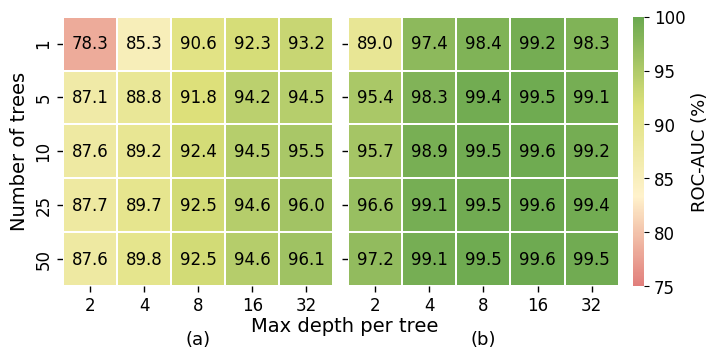

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ---------------- Data ----------------
data_left = [
    [78.31, 85.27, 90.60, 92.27, 93.17],
    [87.13, 88.77, 91.75, 94.22, 94.51],
    [87.62, 89.23, 92.38, 94.46, 95.45],
    [87.71, 89.71, 92.50, 94.56, 95.95],
    [87.64, 89.81, 92.53, 94.62, 96.11],
]

data_right = [
    [89.04, 97.40, 98.42, 99.18, 98.35],
    [95.40, 98.28, 99.37, 99.55, 99.07],
    [95.74, 98.93, 99.48, 99.59, 99.20],
    [96.62, 99.06, 99.51, 99.62, 99.36],
    [97.15, 99.07, 99.53, 99.62, 99.45],
]

n_estimators = [1, 5, 10, 25, 50]
max_depth = [2, 4, 8, 16, 32]

df_left = pd.DataFrame(data_left, index=n_estimators, columns=max_depth)
df_right = pd.DataFrame(data_right, index=n_estimators, columns=max_depth)

# ---------------- Style ----------------
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

hex_colors = ["#E17E7B", "#fff2cc", "#dee17b", "#6aa84f"]
cmap = LinearSegmentedColormap.from_list("custom_colormap", hex_colors)

# ---------------- Figure layout ----------------
fig = plt.figure(figsize=(7.5, 3.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.04], wspace=0.08)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
cax = fig.add_subplot(gs[0, 2])

# LEFT heatmap
sns.heatmap(
    df_left,
    ax=ax1,
    annot=True,
    fmt=".1f",
    cmap=cmap,
    vmin=75, vmax=100,
    linewidths=0.003,
    annot_kws={"color": "black"},
    cbar=False
)

# RIGHT heatmap
hm = sns.heatmap(
    df_right,
    ax=ax2,
    annot=True,
    fmt=".1f",
    cmap=cmap,
    vmin=75, vmax=100,
    linewidths=0.003,
    annot_kws={"color": "black"},
    cbar=True,
    cbar_ax=cax,
    cbar_kws={"label": "ROC-AUC (%)"}
)

# ---------------- Ticks and labels ----------------
for ax in [ax1, ax2]:
    # ax.set_xlabel("Max depth per tree", color="black")
    ax.tick_params(
        axis="both",
        which="both",
        bottom=True,
        left=True,
        labelbottom=True,
        labelleft=True,
        colors="black",
        length=4,
        width=1,
        direction="out"
    )
    ax.invert_yaxis()

ax2.tick_params(labelleft=False)
ax1.set_ylabel("Number of trees", color="black")
ax2.set_ylabel("")
ax1.text(0.5, -0.20, "(a)", transform=ax1.transAxes,
         ha="center", va="center", fontsize=13, color="black")

ax2.text(0.5, -0.20, "(b)", transform=ax2.transAxes,
         ha="center", va="center", fontsize=13, color="black")
fig.text(0.5, -0.02, "Max depth per tree", ha="center", fontsize=14, color="black")

# Make colorbar text black too
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=12, colors="black")
cbar.set_label("ROC-AUC (%)", fontsize=13, color="black")

plt.tight_layout()
plt.savefig("exp2_tree_size/combined_heatmaps.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Exp 3: SHAP

/home/ubuntu/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.3.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ubuntu/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.3.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


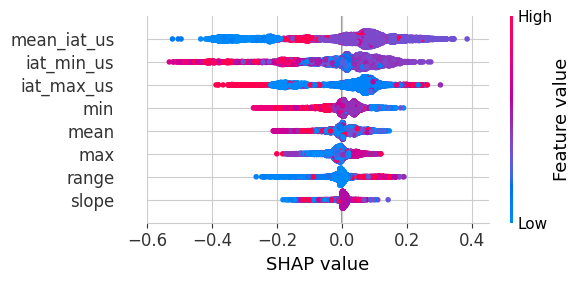

In [26]:
# plot_shap_artifacts.py
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

# Load artifacts
rf_model = joblib.load("exp3_shap/fault/model.pkl")           # not strictly required for plotting but kept for completeness
X_test = pd.read_pickle("exp3_shap/fault/X_test.pkl")
y_test = pd.read_pickle("exp3_shap/fault/y_test.pkl")
shap_pos = np.load("exp3_shap/fault/shap_pos.npy")            # (n_samples, n_features) for positive class
expected_value = float(np.load("exp3_shap/fault/expected_value.npy")[0])

with open("exp3_shap/fault/numeric_cols.json", "r") as f:
    numeric_cols = json.load(f)

shap_df = pd.read_csv("exp3_shap/fault/shap_df.csv")
feature_importances = pd.read_csv("exp3_shap/fault/feature_importances.csv")

# --- SHAP summary plot (global) ---

# # Global font control (same as before)
# plt.rcParams.update({
#     "font.size": 14,
#     "axes.labelsize": 13,
#     "xtick.labelsize": 12,
#     "ytick.labelsize": 12
# })

# Create SHAP plot without auto-show
shap.summary_plot(
    shap_pos,
    X_test,
    feature_names=numeric_cols,
    show=False
)

# Resize figure
plt.gcf().set_size_inches(6, 3)

ax = plt.gca()

# --- Axis limits & ticks ---
ax.set_xlim(-0.6, 0.45)
ax.set_xticks([-0.6, -0.4, -0.2, 0.0, 0.2, 0.4])

# --- Force font sizes (SHAP-safe) ---
for label in ax.get_yticklabels():
    label.set_fontsize(12)

for label in ax.get_xticklabels():
    label.set_fontsize(12)

ax.set_xlabel("SHAP value", fontsize=13)
ax.xaxis.label.set_size(13)

plt.tight_layout()
fig = plt.gcf()
# --- Make colorbar thinner ---
cbar_ax = fig.axes[-1]
pos = cbar_ax.get_position()
cbar_ax.set_position([
    pos.x0,
    pos.y0,
    pos.width * 2,
    pos.height
])
cbar_ax.set_ylabel("Feature value", fontsize=13)

# Layout & save
plt.tight_layout()
plt.savefig("exp3_shap/fault/shap_8f_8ws.pdf", dpi=300)
plt.show()

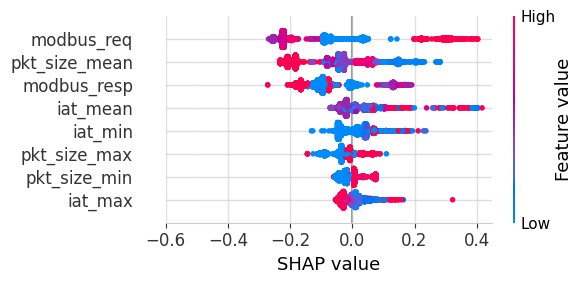

Saved SHAP plot to exp3_shap/attack/shap_8f_8ws.pdf


In [27]:
# plot_shap_artifacts.py
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

ARTIFACT_DIR = "exp3_shap/attack"
OUT_DIR = "exp3_shap/attack"
os.makedirs(OUT_DIR, exist_ok=True)

# Load artifacts
rf_model = joblib.load(os.path.join(ARTIFACT_DIR, "model.pkl"))
X_test = pd.read_pickle(os.path.join(ARTIFACT_DIR, "X_test.pkl"))
y_test = pd.read_pickle(os.path.join(ARTIFACT_DIR, "y_test.pkl"))
shap_pos = np.load(os.path.join(ARTIFACT_DIR, "shap_pos.npy"))
ev = np.load(os.path.join(ARTIFACT_DIR, "expected_value.npy"), allow_pickle=True)
ev = np.asarray(ev).squeeze()
expected_value = ev.item() if ev.shape == () else ev[0]

with open(os.path.join(ARTIFACT_DIR, "numeric_cols.json"), "r") as f:
    numeric_cols = json.load(f)

shap_df = pd.read_csv(os.path.join(ARTIFACT_DIR, "shap_df.csv"))
feature_importances = pd.read_csv(os.path.join(ARTIFACT_DIR, "feature_importances.csv"))

# --- SHAP summary plot (global) ---
shap.summary_plot(
    shap_pos,
    X_test,
    feature_names=numeric_cols,
    show=False
)

plt.gcf().set_size_inches(6, 3)
ax = plt.gca()

# Add grid
ax.grid(True, which='major', axis='both',
        linestyle='-', linewidth=1, alpha=0.6)

# Axis limits & ticks
ax.set_xlim(-0.6, 0.45)
ax.set_xticks([-0.6, -0.4, -0.2, 0.0, 0.2, 0.4])

# Force font sizes
for label in ax.get_yticklabels():
    label.set_fontsize(12)

for label in ax.get_xticklabels():
    label.set_fontsize(12)

ax.set_xlabel("SHAP value", fontsize=13)
ax.xaxis.label.set_size(13)

plt.tight_layout()
fig = plt.gcf()

# Make colorbar thinner
cbar_ax = fig.axes[-1]
pos = cbar_ax.get_position()
cbar_ax.set_position([
    pos.x0,
    pos.y0,
    pos.width * 2,
    pos.height
])
cbar_ax.set_ylabel("Feature value", fontsize=13)

plt.tight_layout()

# Save first, then show
out_path = os.path.join(OUT_DIR, "shap_8f_8ws.pdf")
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved SHAP plot to {out_path}")

/tmp/ipykernel_249637/2151092292.py:11: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)


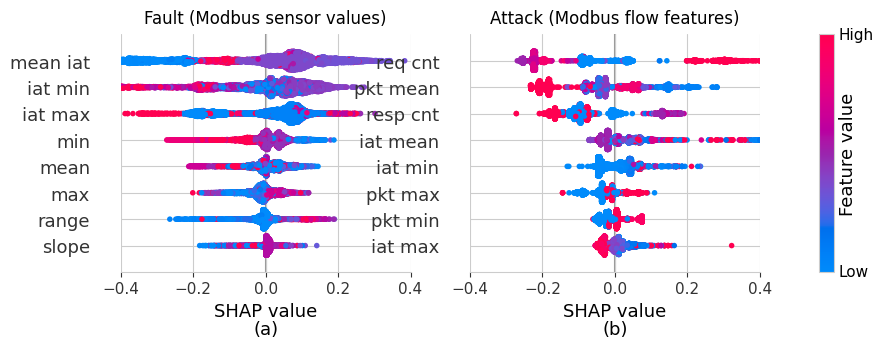

In [50]:
import os
import pickle
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# ---------------- Helpers ----------------
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def load_feature_names(folder, x_obj):
    if isinstance(x_obj, pd.DataFrame):
        return list(x_obj.columns)

    candidates = [
        "feature_list_ws8.txt",
        "shap_feature_list_ws8.txt",
        "feature_list.txt",
        "shap_feature_list.txt",
    ]
    for fname in candidates:
        fpath = os.path.join(folder, fname)
        if os.path.exists(fpath):
            with open(fpath, "r") as f:
                return [line.strip() for line in f if line.strip()]

    return [f"f{i}" for i in range(np.asarray(x_obj).shape[1])]

def prepare_x_df(folder):
    x_path = os.path.join(folder, "X_test.pkl")
    x_obj = load_pickle(x_path)

    if isinstance(x_obj, pd.DataFrame):
        return x_obj.copy()

    x_arr = np.asarray(x_obj)
    feat_names = load_feature_names(folder, x_obj)
    return pd.DataFrame(x_arr, columns=feat_names)

def load_shap_values(folder):
    return np.load(os.path.join(folder, "shap_pos.npy"))

def align_shapes(shap_vals, X_df):
    shap_vals = np.asarray(shap_vals)

    if shap_vals.shape[1] == X_df.shape[1]:
        return shap_vals, X_df

    if shap_vals.shape[0] == X_df.shape[1]:
        return shap_vals.T, X_df

    n = min(shap_vals.shape[1], X_df.shape[1])
    return shap_vals[:, :n], X_df.iloc[:, :n]

def short_rename(df, name_map):
    return df.rename(columns={k: v for k, v in name_map.items() if k in df.columns})

def get_mappable(ax):
    for coll in ax.collections:
        try:
            arr = coll.get_array()
            if arr is not None and len(arr) > 0:
                return coll
        except Exception:
            pass
    return ax.collections[0]

# ---------------- Load data ----------------
attack_folder = "exp3_shap/attack"
fault_folder = "exp3_shap/fault"

X_attack = prepare_x_df(attack_folder)
X_fault = prepare_x_df(fault_folder)

shap_attack = load_shap_values(attack_folder)
shap_fault = load_shap_values(fault_folder)

shap_attack, X_attack = align_shapes(shap_attack, X_attack)
shap_fault, X_fault = align_shapes(shap_fault, X_fault)

attack_name_map = {
    "modbus_req_count": "req cnt",
    "pkt_size_mean": "pkt mean",
    "modbus_resp_count": "resp cnt",
    "iat_mean": "iat mean",
    "iat_min": "iat min",
    "pkt_size_max": "pkt max",
    "pkt_size_min": "pkt min",
    "iat_max": "iat max",
}

fault_name_map = {
    "mean_iat_us": "mean iat",
    "iat_min_us": "iat min",
    "iat_max_us": "iat max",
    "min": "min",
    "mean": "mean",
    "max": "max",
    "range": "range",
    "slope": "slope",
}

X_attack = short_rename(X_attack, attack_name_map)
X_fault = short_rename(X_fault, fault_name_map)

exp_attack = shap.Explanation(
    values=shap_attack,
    data=X_attack.values,
    feature_names=X_attack.columns
)

exp_fault = shap.Explanation(
    values=shap_fault,
    data=X_fault.values,
    feature_names=X_fault.columns
)

# ---------------- Plot ----------------
fig = plt.figure(figsize=(9.2, 3.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.30)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharex=ax1)
cax = fig.add_subplot(gs[0, 2])

shap.plots.beeswarm(
    exp_fault,
    max_display=8,
    show=False,
    ax=ax1,
    plot_size=None,
    color_bar=False
)
ax1.set_title("Fault (Modbus sensor values)", fontsize=12, pad=8)
ax1.set_xlim(-0.4, 0.4)
ax1.set_xlabel("SHAP value", fontsize=13)
ax1.text(0.5, -0.24, "(a)", transform=ax1.transAxes,
         ha="center", va="center", fontsize=13)
ax1.tick_params(axis="y", pad=2)

shap.plots.beeswarm(
    exp_attack,
    max_display=8,
    show=False,
    ax=ax2,
    plot_size=None,
    color_bar=False
)
ax2.set_title("Attack (Modbus flow features)", fontsize=12, pad=8)
ax2.set_xlim(-0.4, 0.4)
ax2.set_xlabel("SHAP value", fontsize=13)
ax2.text(0.5, -0.24, "(b)", transform=ax2.transAxes,
         ha="center", va="center", fontsize=13)
ax2.tick_params(axis="y", pad=2)

mappable = get_mappable(ax2)
cbar = fig.colorbar(mappable, cax=cax)
cbar.set_label("Feature value", fontsize=13)
cbar.set_ticks([])
cbar.ax.text(1.35, 1.00, "High", transform=cbar.ax.transAxes,
             ha="left", va="center", fontsize=11)
cbar.ax.text(1.35, 0.00, "Low", transform=cbar.ax.transAxes,
             ha="left", va="center", fontsize=11)

fig.subplots_adjust(bottom=0.22, top=0.88)
plt.savefig("exp3_shap/fault_attack_shap_summary.pdf", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_249637/3406457438.py:11: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)


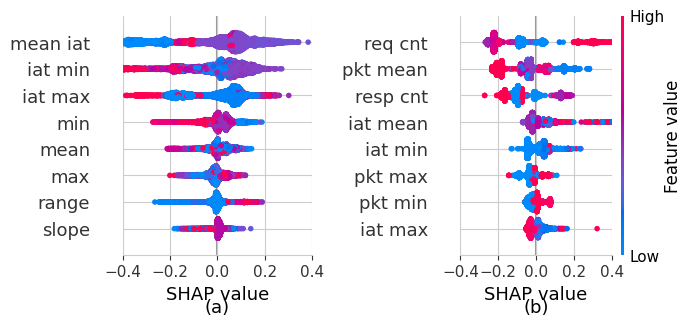

In [52]:
import os
import pickle
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# ---------------- Helpers ----------------
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def load_feature_names(folder, x_obj):
    if isinstance(x_obj, pd.DataFrame):
        return list(x_obj.columns)

    candidates = [
        "feature_list_ws8.txt",
        "shap_feature_list_ws8.txt",
        "feature_list.txt",
        "shap_feature_list.txt",
    ]
    for fname in candidates:
        fpath = os.path.join(folder, fname)
        if os.path.exists(fpath):
            with open(fpath, "r") as f:
                return [line.strip() for line in f if line.strip()]

    return [f"f{i}" for i in range(np.asarray(x_obj).shape[1])]

def prepare_x_df(folder):
    x_path = os.path.join(folder, "X_test.pkl")
    x_obj = load_pickle(x_path)

    if isinstance(x_obj, pd.DataFrame):
        return x_obj.copy()

    x_arr = np.asarray(x_obj)
    feat_names = load_feature_names(folder, x_obj)
    return pd.DataFrame(x_arr, columns=feat_names)

def load_shap_values(folder):
    return np.load(os.path.join(folder, "shap_pos.npy"))

def align_shapes(shap_vals, X_df):
    shap_vals = np.asarray(shap_vals)

    if shap_vals.shape[1] == X_df.shape[1]:
        return shap_vals, X_df

    if shap_vals.shape[0] == X_df.shape[1]:
        return shap_vals.T, X_df

    n = min(shap_vals.shape[1], X_df.shape[1])
    return shap_vals[:, :n], X_df.iloc[:, :n]

# ---------------- Load data ----------------
attack_folder = "exp3_shap/attack"
fault_folder = "exp3_shap/fault"

X_attack = prepare_x_df(attack_folder)
X_fault = prepare_x_df(fault_folder)

shap_attack = load_shap_values(attack_folder)
shap_fault = load_shap_values(fault_folder)

shap_attack, X_attack = align_shapes(shap_attack, X_attack)
shap_fault, X_fault = align_shapes(shap_fault, X_fault)

# ---------------- Short feature names ----------------
attack_name_map = {
    "modbus_req_count": "req cnt",
    "pkt_size_mean": "pkt mean",
    "modbus_resp_count": "resp cnt",
    "iat_mean": "iat mean",
    "iat_min": "iat min",
    "pkt_size_max": "pkt max",
    "pkt_size_min": "pkt min",
    "iat_max": "iat max",
}

fault_name_map = {
    "mean_iat_us": "mean iat",
    "iat_min_us": "iat min",
    "iat_max_us": "iat max",
    "min": "min",
    "mean": "mean",
    "max": "max",
    "range": "range",
    "slope": "slope",
}

X_attack = X_attack.rename(columns=attack_name_map)
X_fault = X_fault.rename(columns=fault_name_map)

exp_attack = shap.Explanation(
    values=shap_attack,
    data=X_attack.values,
    feature_names=X_attack.columns
)

exp_fault = shap.Explanation(
    values=shap_fault,
    data=X_fault.values,
    feature_names=X_fault.columns
)

# ---------------- Plot side by side ----------------
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), sharex=True)

# Left: Fault
shap.plots.beeswarm(
    exp_fault,
    max_display=8,
    show=False,
    ax=axes[0],
    plot_size=None,
    color_bar=False
)
# axes[0].set_title("Fault (Modbus sensor values)", fontsize=14)
axes[0].set_xlim(-0.4, 0.4)
axes[0].set_xlabel("SHAP value", fontsize=13)
axes[0].text(0.5, -0.22, "(a)", transform=axes[0].transAxes,
             ha="center", va="center", fontsize=13)

# Right: Attack
shap.plots.beeswarm(
    exp_attack,
    max_display=8,
    show=False,
    ax=axes[1],
    plot_size=None,
    color_bar=True
)
# axes[1].set_title("Attack (Modbus flow features)", fontsize=14)
axes[1].set_xlim(-0.4, 0.4)
axes[1].set_xlabel("SHAP value", fontsize=13)
axes[1].text(0.5, -0.22, "(b)", transform=axes[1].transAxes,
             ha="center", va="center", fontsize=13)

for ax in axes:
    ax.set_xlim(-0.4, 0.4)

plt.tight_layout()
plt.savefig("exp3_shap/fault_attack_shap_summary.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Exp 4: Online

File: latencies_rf_ws8_depth32_est1.csv | col='rf_ns' | n=27533 | min=0.03 | max=115.79 | median=0.21 | mean=0.29 | std=2.32
File: latencies_rf_ws8_depth32_est5.csv | col='rf_ns' | n=27533 | min=0.05 | max=287.23 | median=3.28 | mean=3.38 | std=4.98
File: latencies_rf_ws8_depth32_est10.csv | col='rf_ns' | n=27533 | min=0.10 | max=293.70 | median=9.20 | mean=8.80 | std=8.79
File: latencies_rf_ws8_depth32_est25.csv | col='rf_ns' | n=27533 | min=0.27 | max=355.64 | median=29.28 | mean=27.74 | std=22.27
File: latencies_rf_ws8_depth32_est50.csv | col='rf_ns' | n=27533 | min=0.48 | max=437.85 | median=72.00 | mean=66.04 | std=47.32


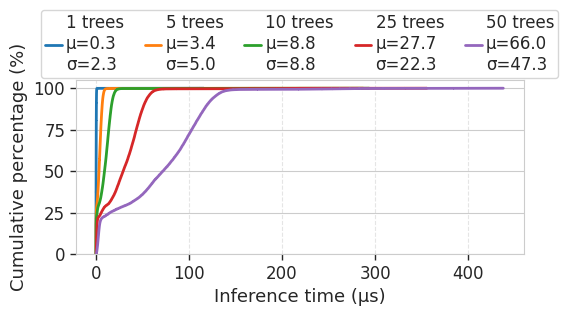

In [3]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "exp4_online/fault"
PATTERN = "latencies_rf_ws8_depth32_est*.csv"
OUT_PLOT = os.path.join(DATA_DIR, "latency_cdfs_ws8_depth32.pdf")

FIGSIZE = (6, 4.25)
LINEWIDTH = 2
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]  # 5 distinct colors
MARKERS = [None]*5

# Helper: choose a latency column
def find_latency_column(df):
    candidates = [c for c in df.columns if c.lower() in (
        'latency','lat_ms','latency_ms','response_time','response_ms','lat','rtt','rt_ms')]
    if candidates:
        return candidates[0]
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    for c in numeric_cols:
        if df[c].dropna().size > 0:
            vals = pd.to_numeric(df[c], errors='coerce').dropna().values
            if vals.size > 10:
                diffs = np.diff(vals.astype(float))
                if np.all(diffs == 1) or np.all(diffs == 0):
                    continue
            return c
    raise RuntimeError("No suitable numeric column found for latency.")

def extract_est(fp):
    m = re.search(r"est(\d+)", os.path.basename(fp))
    return int(m.group(1)) if m else float("inf")

# Find files and sort by numeric est value (1,5,10,25,50)
files = sorted(
    glob.glob(os.path.join(DATA_DIR, PATTERN)),
    key=extract_est
)

if not files:
    raise RuntimeError(f"No files found matching {PATTERN} in {DATA_DIR}")

plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})
fig, ax = plt.subplots(figsize=FIGSIZE)

handles = []
labels = []

for i, fp in enumerate(files):
    df = pd.read_csv(fp)
    lat_col = find_latency_column(df)
    vals = pd.to_numeric(df[lat_col], errors='coerce').dropna().astype(float).values

    # --- Convert from nanoseconds to microseconds ---
    # NOTE: original data are ns -> divide by 1000 to get μs
    vals = vals / 1000.0

    # Debug summary
    if len(vals):
        mean_lat = np.mean(vals)
        std_lat = np.std(vals, ddof=1)
        print(
            f"File: {os.path.basename(fp)} | col='{lat_col}' | "
            f"n={len(vals)} | "
            f"min={np.min(vals):.2f} | "
            f"max={np.max(vals):.2f} | "
            f"median={np.median(vals):.2f} | "
            f"mean={mean_lat:.2f} | "
            f"std={std_lat:.2f}"
        )
    else:
        print(f"File: {os.path.basename(fp)} | col='{lat_col}' | n=0 | no valid values")
        continue

    # sort and CDF (percentage)
    vals_sorted = np.sort(vals)
    n = vals_sorted.size
    y = np.arange(1, n + 1) / n * 100.0

    # extract numeric trees count
    trees = extract_est(fp)

    color = COLORS[i % len(COLORS)]

    # Use plot with drawstyle='steps-post' to get a Line2D handle
    line, = ax.plot(vals_sorted, y, drawstyle='steps-post',
                    linewidth=LINEWIDTH, color=color)

    # Save handle and a two-line legend label: first line = trees, second line = stats
    label = (
        f"{trees} trees\n"
        f"μ={mean_lat:.1f}\n"
        f"σ={std_lat:.1f}"
    )
    handles.append(line)
    labels.append(label)

    # optional: markers downsample
    if MARKERS[i]:
        idx = np.linspace(0, n-1, min(80, n)).astype(int)
        ax.plot(vals_sorted[idx], y[idx], linestyle='None',
                marker=MARKERS[i], color=color, markersize=4)

# Cosmetics
ax.set_xlabel("Inference time (μs)")
ax.set_ylabel("Cumulative percentage (%)")
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_ylim(0, 105)
# ax.set_xscale("symlog")

ax.tick_params(
    axis='both',        # x and y
    which='both',       # major + minor ticks
    direction='out',     # ticks point inward (paper style)
    length=4,           # tick length
    width=1,
    bottom=True,
    top=False,           # 🔴 show top tick marks
    left=True,
    right=False          # 🔴 show right tick marks
)

# Legend above plot, multi-column, with title explaining the numbers are tree counts
legend = ax.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.45),  # slightly higher for 3-line entries
    ncol=5,                     
    frameon=True,
    # title="Number of trees"
    columnspacing=1.25,     # horizontal spacing between columns
    handletextpad=0.25,     # space between line symbol and text
    labelspacing=0.1,      # vertical spacing between lines
    borderpad=0.25,          # padding inside legend box
    handlelength=1 
)

# Make legend title clarify units (optional)
legend.get_title().set_fontsize(10)
# Left-align multiline legend texts
for text in legend.get_texts():
    text.set_multialignment('left')

# Tight layout and save
plt.tight_layout()
os.makedirs(os.path.dirname(OUT_PLOT) or ".", exist_ok=True)
plt.savefig(OUT_PLOT, dpi=300, bbox_inches='tight')
plt.show()

File: latencies_att_rf_ws8_depth8_est1.csv | col='rf_ns' | n=302928 | min=0.04 | max=346.06 | median=0.06 | mean=0.11 | std=2.34
File: latencies_att_rf_ws8_depth8_est5.csv | col='rf_ns' | n=302928 | min=0.11 | max=255.33 | median=0.14 | mean=0.20 | std=2.26
File: latencies_att_rf_ws8_depth8_est10.csv | col='rf_ns' | n=302928 | min=0.20 | max=353.58 | median=0.27 | mean=0.33 | std=2.54
File: latencies_att_rf_ws8_depth8_est25.csv | col='rf_ns' | n=302928 | min=0.53 | max=278.06 | median=0.67 | mean=0.79 | std=2.83
File: latencies_att_rf_ws8_depth8_est50.csv | col='rf_ns' | n=302928 | min=1.05 | max=289.56 | median=1.34 | mean=1.61 | std=3.37


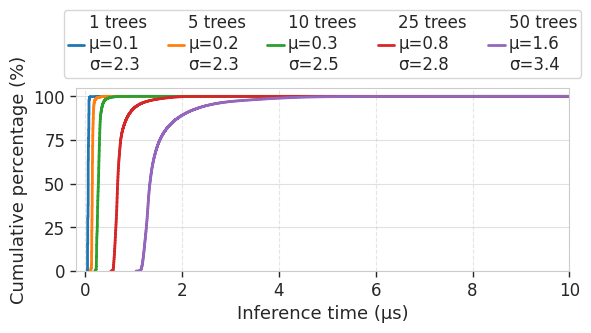

In [4]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "exp4_online/attack"
PATTERN = "latencies_att_rf_ws8_depth8_est*.csv"
OUT_PLOT = os.path.join(DATA_DIR, "latency_cdfs_ws8_depth8.pdf")

FIGSIZE = (6.3, 4.5)
LINEWIDTH = 2
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]  # 5 distinct colors
MARKERS = [None]*5

# Helper: choose a latency column
def find_latency_column(df):
    candidates = [c for c in df.columns if c.lower() in (
        'latency','lat_ms','latency_ms','response_time','response_ms','lat','rtt','rt_ms')]
    if candidates:
        return candidates[0]
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    for c in numeric_cols:
        if df[c].dropna().size > 0:
            vals = pd.to_numeric(df[c], errors='coerce').dropna().values
            if vals.size > 10:
                diffs = np.diff(vals.astype(float))
                if np.all(diffs == 1) or np.all(diffs == 0):
                    continue
            return c
    raise RuntimeError("No suitable numeric column found for latency.")

def extract_est(fp):
    m = re.search(r"est(\d+)", os.path.basename(fp))
    return int(m.group(1)) if m else float("inf")

# Find files and sort by numeric est value (1,5,10,25,50)
files = sorted(
    glob.glob(os.path.join(DATA_DIR, PATTERN)),
    key=extract_est
)

if not files:
    raise RuntimeError(f"No files found matching {PATTERN} in {DATA_DIR}")

plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})
fig, ax = plt.subplots(figsize=FIGSIZE)

handles = []
labels = []

for i, fp in enumerate(files):
    df = pd.read_csv(fp)
    lat_col = find_latency_column(df)
    vals = pd.to_numeric(df[lat_col], errors='coerce').dropna().astype(float).values

    # --- Convert from nanoseconds to microseconds ---
    # NOTE: original data are ns -> divide by 1000 to get μs
    vals = vals / 1000.0

    # Debug summary
    if len(vals):
        mean_lat = np.mean(vals)
        std_lat = np.std(vals, ddof=1)
        print(
            f"File: {os.path.basename(fp)} | col='{lat_col}' | "
            f"n={len(vals)} | "
            f"min={np.min(vals):.2f} | "
            f"max={np.max(vals):.2f} | "
            f"median={np.median(vals):.2f} | "
            f"mean={mean_lat:.2f} | "
            f"std={std_lat:.2f}"
        )
    else:
        print(f"File: {os.path.basename(fp)} | col='{lat_col}' | n=0 | no valid values")
        continue

    # sort and CDF (percentage)
    vals_sorted = np.sort(vals)
    n = vals_sorted.size
    y = np.arange(1, n + 1) / n * 100.0

    # extract numeric trees count
    trees = extract_est(fp)

    color = COLORS[i % len(COLORS)]

    # Use plot with drawstyle='steps-post' to get a Line2D handle
    line, = ax.plot(vals_sorted, y, drawstyle='steps-post',
                    linewidth=LINEWIDTH, color=color)

    # Save handle and a two-line legend label: first line = trees, second line = stats
    label = (
        f"{trees} trees\n"
        f"μ={mean_lat:.1f}\n"
        f"σ={std_lat:.1f}"
    )
    handles.append(line)
    labels.append(label)

    # optional: markers downsample
    if MARKERS[i]:
        idx = np.linspace(0, n-1, min(80, n)).astype(int)
        ax.plot(vals_sorted[idx], y[idx], linestyle='None',
                marker=MARKERS[i], color=color, markersize=4)

# Cosmetics
ax.set_xlabel("Inference time (μs)")
ax.set_ylabel("Cumulative percentage (%)")
# Y grid (solid)
ax.grid(True, axis='y', linestyle='-', linewidth=0.8, alpha=0.6)
# X grid (dashed)
ax.grid(True, axis='x', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_ylim(0, 105)
ax.set_xlim(-0.2, 10)
# ax.set_xscale("symlog")

ax.tick_params(
    axis='both',        # x and y
    which='both',       # major + minor ticks
    direction='out',     # ticks point inward (paper style)
    length=4,           # tick length
    width=1,
    bottom=True,
    top=False,           # 🔴 show top tick marks
    left=True,
    right=False          # 🔴 show right tick marks
)

# Legend above plot, multi-column, with title explaining the numbers are tree counts
legend = ax.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.47),  # slightly higher for 3-line entries
    ncol=5,                     
    frameon=True,
    # title="Number of trees"
    columnspacing=1.25,     # horizontal spacing between columns
    handletextpad=0.25,     # space between line symbol and text
    labelspacing=0.1,      # vertical spacing between lines
    borderpad=0.25,          # padding inside legend box
    handlelength=1 
)

# Make legend title clarify units (optional)
legend.get_title().set_fontsize(10)
# Left-align multiline legend texts
for text in legend.get_texts():
    text.set_multialignment('left')

fig.subplots_adjust(left=0.001, right=1.5)

# Tight layout and save
plt.tight_layout()
os.makedirs(os.path.dirname(OUT_PLOT) or ".", exist_ok=True)
plt.savefig(OUT_PLOT, dpi=300, bbox_inches='tight')
plt.show()


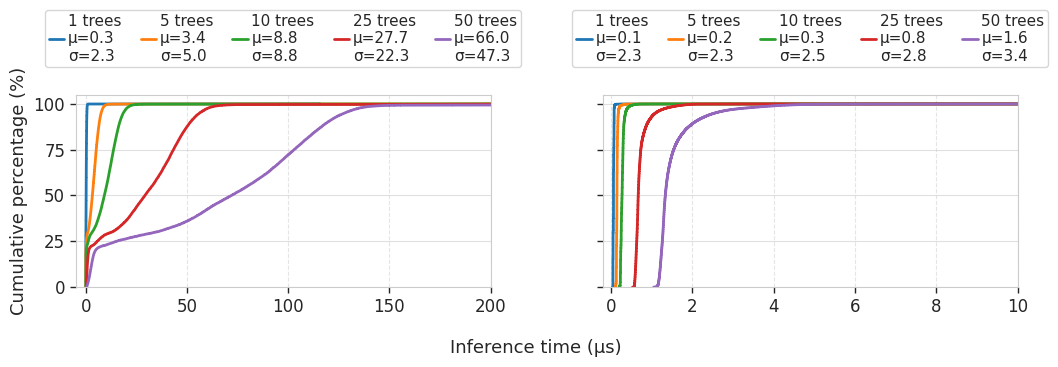

In [20]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Config ----------------
FAULT_DIR = "exp4_online/fault"
ATTACK_DIR = "exp4_online/attack"

FAULT_PATTERN = "latencies_rf_ws8_depth32_est*.csv"
ATTACK_PATTERN = "latencies_att_rf_ws8_depth8_est*.csv"

OUT_PLOT = "exp4_online/combined_latency_cdfs.pdf"

FIGSIZE = (11, 4.5)
LINEWIDTH = 2
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11
})

# ---------------- Helpers ----------------
def find_latency_column(df):
    candidates = [c for c in df.columns if c.lower() in (
        "latency", "lat_ms", "latency_ms", "response_time", "response_ms", "lat", "rtt", "rt_ms"
    )]
    if candidates:
        return candidates[0]

    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    for c in numeric_cols:
        vals = pd.to_numeric(df[c], errors="coerce").dropna().values
        if vals.size > 10:
            diffs = np.diff(vals.astype(float))
            if np.all(diffs == 1) or np.all(diffs == 0):
                continue
        return c

    raise RuntimeError("No suitable numeric column found for latency.")

def extract_est(fp):
    m = re.search(r"est(\d+)", os.path.basename(fp))
    return int(m.group(1)) if m else float("inf")

def plot_cdf(ax, data_dir, pattern, xlim=None):
    files = sorted(glob.glob(os.path.join(data_dir, pattern)), key=extract_est)
    if not files:
        raise RuntimeError(f"No files found matching {pattern} in {data_dir}")

    handles = []
    labels = []

    for i, fp in enumerate(files):
        df = pd.read_csv(fp)
        lat_col = find_latency_column(df)

        vals = pd.to_numeric(df[lat_col], errors="coerce").dropna().astype(float).values
        vals = vals / 1000.0  # ns -> us

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)
        n = vals_sorted.size
        y = np.arange(1, n + 1) / n * 100.0

        trees = extract_est(fp)
        mean_lat = np.mean(vals_sorted)
        std_lat = np.std(vals_sorted, ddof=1)

        color = COLORS[i % len(COLORS)]
        line, = ax.plot(vals_sorted, y, drawstyle="steps-post",
                        linewidth=LINEWIDTH, color=color)

        handles.append(line)
        labels.append(f"{trees} trees\nμ={mean_lat:.1f}\nσ={std_lat:.1f}")

    ax.set_ylim(0, 105)
    if xlim is not None:
        ax.set_xlim(*xlim)

    ax.grid(True, axis="y", linestyle="-", linewidth=0.8, alpha=0.6)
    ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.5)

    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
        length=4,
        width=1,
        bottom=True,
        top=False,
        left=True,
        right=False
    )

    return handles, labels

# ---------------- Plot ----------------
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Fault
h1, l1 = plot_cdf(axes[0], FAULT_DIR, FAULT_PATTERN)
# axes[0].set_title("(a) Fault")
# axes[0].set_xlabel("Inference time (μs)")
axes[0].set_ylabel("Cumulative percentage (%)")
axes[0].set_xlim(-5, 200)

# Attack
h2, l2 = plot_cdf(axes[1], ATTACK_DIR, ATTACK_PATTERN, xlim=(-0.2, 10))
# axes[1].set_title("(b) Attack")
# axes[1].set_xlabel("Inference time (μs)")
axes[1].set_ylabel("")
axes[1].set_xlim(-0.2, 10)
axes[1].tick_params(labelleft=False)

fig.text(0.5, 0.02, "Inference time (μs)", ha="center", fontsize=13)

# Legends
axes[0].legend(
    h1, l1,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.48),
    ncol=5,
    frameon=True,
    columnspacing=1.25,
    handletextpad=0.25,
    labelspacing=0.1,
    borderpad=0.25,
    handlelength=1
)

axes[1].legend(
    h2, l2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.48),
    ncol=5,
    frameon=True,
    columnspacing=1.25,
    handletextpad=0.25,
    labelspacing=0.1,
    borderpad=0.25,
    handlelength=1
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(OUT_PLOT, dpi=300, bbox_inches="tight")
plt.show()

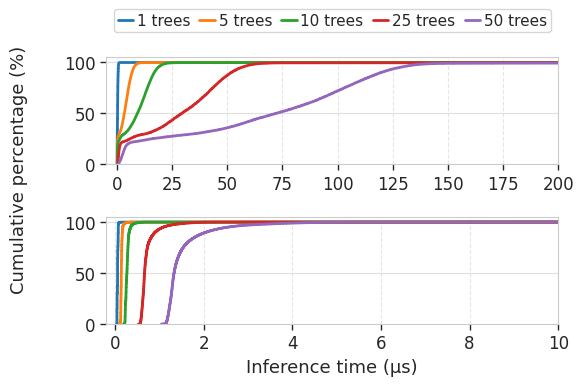

In [58]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Config ----------------
FAULT_DIR = "exp4_online/fault"
ATTACK_DIR = "exp4_online/attack"

FAULT_PATTERN = "latencies_rf_ws8_depth32_est*.csv"
ATTACK_PATTERN = "latencies_att_rf_ws8_depth8_est*.csv"

OUT_PLOT = "exp4_online/combined_latency_cdfs.pdf"

FIGSIZE = (6, 5.5)
LINEWIDTH = 2
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11
})

# ---------------- Helpers ----------------
def find_latency_column(df):
    candidates = [
        c for c in df.columns
        if c.lower() in (
            "latency", "lat_ms", "latency_ms", "response_time",
            "response_ms", "lat", "rtt", "rt_ms"
        )
    ]
    if candidates:
        return candidates[0]

    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    for c in numeric_cols:
        vals = pd.to_numeric(df[c], errors="coerce").dropna().values
        if vals.size > 10:
            diffs = np.diff(vals.astype(float))
            if np.all(diffs == 1) or np.all(diffs == 0):
                continue
        return c

    raise RuntimeError("No suitable numeric column found for latency.")

def extract_est(fp):
    m = re.search(r"est(\d+)", os.path.basename(fp))
    return int(m.group(1)) if m else float("inf")

def plot_cdf(ax, data_dir, pattern, xlim=None):
    files = sorted(glob.glob(os.path.join(data_dir, pattern)), key=extract_est)
    if not files:
        raise RuntimeError(f"No files found matching {pattern} in {data_dir}")

    handles = []
    labels = []

    for i, fp in enumerate(files):
        df = pd.read_csv(fp)
        lat_col = find_latency_column(df)

        vals = pd.to_numeric(df[lat_col], errors="coerce").dropna().astype(float).values
        vals = vals / 1000.0  # ns -> us

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)
        n = vals_sorted.size
        y = np.arange(1, n + 1) / n * 100.0

        trees = extract_est(fp)
        mean_lat = np.mean(vals_sorted)
        std_lat = np.std(vals_sorted, ddof=1)

        color = COLORS[i % len(COLORS)]
        line, = ax.plot(
            vals_sorted,
            y,
            drawstyle="steps-post",
            linewidth=LINEWIDTH,
            color=color
        )

        handles.append(line)
        # labels.append(f"{trees} trees\nμ={mean_lat:.1f}\nσ={std_lat:.1f}")
        labels.append(f"{trees} trees")

    ax.set_ylim(0, 105)
    if xlim is not None:
        ax.set_xlim(*xlim)

    ax.grid(True, axis="y", linestyle="-", linewidth=0.8, alpha=0.6)
    ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.5)

    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
        length=4,
        width=1,
        bottom=True,
        top=False,
        left=True,
        right=False
    )

    return handles, labels

# ---------------- Plot ----------------
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE)

# Top: Fault
h1, l1 = plot_cdf(axes[0], FAULT_DIR, FAULT_PATTERN)
# axes[0].set_ylabel("Cumulative percentage (%)")
# axes[0].set_xlabel("Inference time (μs)")
axes[0].set_xlim(-5, 200)
# axes[0].set_title("(a) Fault", fontsize=12, pad=8)
axes[0].legend(
    h1, l1,
    loc="upper center",
    bbox_to_anchor=(0, 1.02, 1, 0.5),
    mode="expand",
    ncol=5,
    frameon=True,
    columnspacing=1.25,
    handletextpad=0.25,
    labelspacing=0.1,
    borderpad=0.25,
    handlelength=1
)

# Bottom: Attack
h2, l2 = plot_cdf(axes[1], ATTACK_DIR, ATTACK_PATTERN, xlim=(-0.2, 10))
# axes[1].set_ylabel("Cumulative percentage (%)")
axes[1].set_xlim(-0.2, 10)
axes[1].set_xlabel("Inference time (μs)")
# axes[1].set_title("(b) Attack", fontsize=12, pad=8)
# axes[1].tick_params(labelleft=False)
# axes[1].legend(
#     h2, l2,
#     loc="upper center",
#     bbox_to_anchor=(0.5, 1.34),
#     ncol=5,
#     frameon=True,
#     columnspacing=1.25,
#     handletextpad=0.25,
#     labelspacing=0.1,
#     borderpad=0.25,
#     handlelength=1
# )

fig.supylabel("Cumulative percentage (%)", fontsize=13)

# Layout / save
plt.subplots_adjust(hspace=0.55, top=0.92, bottom=0.10, left=0.09, right=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.9])
os.makedirs(os.path.dirname(OUT_PLOT), exist_ok=True)
plt.savefig(OUT_PLOT, dpi=300, bbox_inches="tight")
plt.show()